# IMB Profiles & Phase 1 Novelty Test: max(IMB) vs DD R²

This notebook demonstrates the computation of **Instantaneous Memory Burden (IMB) profiles** across UD treebanks and executes the **Phase 1 novelty test** by regressing max(IMB) on DD moments and tree properties.

**Key steps:**
1. **Core IMB computation** - Standard and encounter-only IMB profiles for dependency trees
2. **Worked example replication** - Two 5-node trees with identical DD multisets but different IMB profiles
3. **Decomposition identity verification** - Confirms total_IMB = sum(d_k*(d_k+1)/2)
4. **Phase 1 novelty test** - Pooled OLS regression of max(IMB) on 7 predictors; encounter-only variant falls below 0.90 R² threshold, confirming novel signal
5. **Per-treebank regression** - R² stratified by head type (head-final, head-initial, mixed)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# statsmodels — NOT pre-installed on Colab
_pip('statsmodels==0.14.6')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python>=3.11 (Colab); use latest available for local Python
    _pip('scipy>=1.13,<2')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/experiment_iter2_imb_profiles_ph/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['sentences'])} sentences from {len(data['typology'])} treebanks")
print(f"Head types: {data['head_type_map']}")

Loaded 105 sentences from 3 treebanks
Head types: {'ab_abnc': 'head_final', 'sq_staf': 'head_initial', 'af_afribooms': 'mixed'}


In [5]:
# ============================================================
# CONFIG — tunable parameters (set to minimum for demo)
# ============================================================

# Minimum sentences per treebank to run regression
# Original: 30 (for meaningful OLS with 7 predictors + constant)
MIN_SENTENCES_FOR_REGRESSION = 8

# Predictors for OLS regression of max(IMB) on DD moments + tree properties
PREDICTORS = ["mean_dd", "dd_variance", "dd_skewness", "sentence_length",
              "tree_depth", "max_arity", "mean_arity"]

# Number of decomposition spot-checks (1 = check every sentence)
SPOT_CHECK_EVERY_N = 1

## Core IMB Computation Functions

The **Instantaneous Memory Burden (IMB)** at each position counts the cumulative age of all open dependencies. The **standard** variant counts all dependencies; the **encounter-only** variant restricts to head-initial dependencies (where the head has already been seen).

In [6]:
def compute_imb_profile_standard(heads: list[int]) -> list[float]:
    """Compute standard IMB at each position.

    heads: list of length n (0-indexed array). heads[i] is the 1-indexed head
           of token at 1-indexed position (i+1). heads[i]==0 means root.

    Returns: imb_profile of length n (0-indexed, imb_profile[j] = IMB at position j+1)
    """
    n = len(heads)
    imb = [0.0] * n

    for i in range(n):
        dep_pos = i + 1        # 1-indexed position of dependent
        head_pos = heads[i]    # 1-indexed position of head
        if head_pos == 0:
            continue            # root, skip
        lo = min(dep_pos, head_pos)
        hi = max(dep_pos, head_pos)
        # This dependency is open at positions lo..hi (1-indexed)
        # At position j (1-indexed), age = j - lo
        for j_1idx in range(lo, hi + 1):
            imb[j_1idx - 1] += (j_1idx - lo)

    return imb


def compute_imb_profile_encounter_only(heads: list[int]) -> list[float]:
    """Compute encounter-only IMB variant.

    For head-final deps (head_pos > dep_pos): skip (head not yet encountered)
    For head-initial deps (head_pos < dep_pos): same as standard
    """
    n = len(heads)
    imb_enc = [0.0] * n

    for i in range(n):
        dep_pos = i + 1
        head_pos = heads[i]
        if head_pos == 0:
            continue
        lo = min(dep_pos, head_pos)
        hi = max(dep_pos, head_pos)

        if head_pos < dep_pos:
            # Head-initial: both encountered by position dep_pos
            for j_1idx in range(lo, hi + 1):
                imb_enc[j_1idx - 1] += (j_1idx - lo)
        # else: Head-final: skip entirely

    return imb_enc


def extract_imb_features(imb_profile: list[float]) -> dict:
    """Extract summary statistics from an IMB profile."""
    n = len(imb_profile)
    if n == 0:
        return {"total_imb": 0.0, "max_imb": 0.0, "mean_imb": 0.0,
                "llf": 1.0, "imb_variance": 0.0}
    total_imb = sum(imb_profile)
    max_imb = max(imb_profile)
    mean_imb = total_imb / n
    llf = mean_imb / max_imb if max_imb > 0 else 1.0
    if n > 1:
        imb_var = sum((x - mean_imb) ** 2 for x in imb_profile) / n
    else:
        imb_var = 0.0
    return {
        "total_imb": total_imb,
        "max_imb": max_imb,
        "mean_imb": round(mean_imb, 6),
        "llf": round(llf, 6),
        "imb_variance": round(imb_var, 6),
    }


def verify_decomposition(dd_list: list[int], total_imb: float) -> bool:
    """Verify total_imb == sum(d*(d+1)/2 for d in dd_list)."""
    expected = sum(d * (d + 1) / 2 for d in dd_list)
    return abs(total_imb - expected) < 1e-6

print("IMB computation functions defined.")

IMB computation functions defined.


## Worked Example Replication

Two 5-node trees share identical DD multisets {1,1,2,2} but produce different IMB profiles, max values (3 vs 2), and quadratic costs (18 vs 16), while linear costs are identical. This demonstrates that IMB captures temporal overlap invisible to DD statistics.

In [7]:
# Tree A: linear chain 1->2->3->4, plus 5->3
WORKED_A_HEADS = [0, 1, 2, 2, 3]
# Tree B: star from root, then 3->4 and 3->5
WORKED_B_HEADS = [0, 1, 1, 3, 3]

imb_a = compute_imb_profile_standard(WORKED_A_HEADS)
imb_b = compute_imb_profile_standard(WORKED_B_HEADS)
feat_a = extract_imb_features(imb_a)
feat_b = extract_imb_features(imb_b)

# Verify expected values
assert imb_a == [0, 1, 2, 3, 2], f"Tree A IMB mismatch: {imb_a}"
assert imb_b == [0, 2, 2, 2, 2], f"Tree B IMB mismatch: {imb_b}"
assert feat_a["max_imb"] == 3, f"Tree A max_imb={feat_a['max_imb']}, expected 3"
assert feat_b["max_imb"] == 2, f"Tree B max_imb={feat_b['max_imb']}, expected 2"

# DD multisets
dd_a = [abs((i + 1) - WORKED_A_HEADS[i]) for i in range(5) if WORKED_A_HEADS[i] != 0]
dd_b = [abs((i + 1) - WORKED_B_HEADS[i]) for i in range(5) if WORKED_B_HEADS[i] != 0]
assert sorted(dd_a) == sorted(dd_b) == [1, 1, 2, 2], \
    f"DD multisets mismatch: {sorted(dd_a)} vs {sorted(dd_b)}"

# Quadratic cost
cost_a_quad = sum(x ** 2 for x in imb_a)
cost_b_quad = sum(x ** 2 for x in imb_b)
assert cost_a_quad == 18 and cost_b_quad == 16, \
    f"Quad costs: A={cost_a_quad}, B={cost_b_quad}"

# Linear cost (identical)
cost_a_lin = sum(imb_a)
cost_b_lin = sum(imb_b)
assert cost_a_lin == cost_b_lin == 8, \
    f"Linear costs: A={cost_a_lin}, B={cost_b_lin}"

# Decomposition identity
assert verify_decomposition(dd_a, feat_a["total_imb"]), "Decomp failed Tree A"
assert verify_decomposition(dd_b, feat_b["total_imb"]), "Decomp failed Tree B"

print("=== Worked Example Results ===")
print(f"Tree A: heads={WORKED_A_HEADS}, IMB={imb_a}, max_imb={feat_a['max_imb']}, LLF={feat_a['llf']:.3f}")
print(f"Tree B: heads={WORKED_B_HEADS}, IMB={imb_b}, max_imb={feat_b['max_imb']}, LLF={feat_b['llf']:.3f}")
print(f"DD multisets: A={sorted(dd_a)}, B={sorted(dd_b)} (IDENTICAL)")
print(f"Quadratic cost: A={cost_a_quad}, B={cost_b_quad} (reduction={100*(cost_a_quad-cost_b_quad)/cost_a_quad:.1f}%)")
print(f"Linear cost: A={cost_a_lin}, B={cost_b_lin} (identical={cost_a_lin==cost_b_lin})")
print("ALL ASSERTIONS PASSED")

=== Worked Example Results ===
Tree A: heads=[0, 1, 2, 2, 3], IMB=[0.0, 1.0, 2.0, 3.0, 2.0], max_imb=3.0, LLF=0.533
Tree B: heads=[0, 1, 1, 3, 3], IMB=[0.0, 2.0, 2.0, 2.0, 2.0], max_imb=2.0, LLF=0.800
DD multisets: A=[1, 1, 2, 2], B=[1, 1, 2, 2] (IDENTICAL)
Quadratic cost: A=18.0, B=16.0 (reduction=11.1%)
Linear cost: A=8.0, B=8.0 (identical=True)
ALL ASSERTIONS PASSED


## Edge Case Tests

Validate IMB computation on simple trees: single dependency, left-branching chain, star topology, and encounter-only correctness.

In [8]:
# Single dependency: token 1 is root, token 2 has head at position 1
imb = compute_imb_profile_standard([0, 1])
assert imb == [0, 1], f"Single dep: {imb}"
feat = extract_imb_features(imb)
assert feat["max_imb"] == 1
assert abs(feat["llf"] - 0.5) < 1e-6

# Left-branching chain: 1<-2<-3<-4 (root is 4)
imb_lb = compute_imb_profile_standard([2, 3, 4, 0])
assert imb_lb == [0, 1, 1, 1], f"Left-branch: {imb_lb}"

# Star topology: all from root at position 1
imb_star = compute_imb_profile_standard([0, 1, 1, 1])
assert imb_star == [0, 3, 4, 3], f"Star: {imb_star}"

# Encounter-only on head-final: all deps are head-final, so should be all zeros
imb_enc = compute_imb_profile_encounter_only([3, 3, 0])
assert imb_enc == [0, 0, 0], f"Enc head-final: {imb_enc}"

# Encounter-only on head-initial: should equal standard
imb_enc2 = compute_imb_profile_encounter_only([0, 1, 1])
imb_std2 = compute_imb_profile_standard([0, 1, 1])
assert imb_enc2 == imb_std2, f"Enc head-initial mismatch: {imb_enc2} vs {imb_std2}"

# Verify encounter-only <= standard for all positions
test_heads = [0, 1, 2, 2, 3]
imb_s = compute_imb_profile_standard(test_heads)
imb_e = compute_imb_profile_encounter_only(test_heads)
for j in range(len(test_heads)):
    assert imb_e[j] <= imb_s[j] + 1e-9, \
        f"Enc > Std at pos {j}: {imb_e[j]} > {imb_s[j]}"

print("Edge case tests: ALL PASSED")

Edge case tests: ALL PASSED


## Process Sentences from UD Treebanks

Compute IMB profiles for each sentence, verify the decomposition identity, and collect features for regression analysis.

In [9]:
t0 = time.time()

typology_lookup = data["typology"]
head_type_map = data["head_type_map"]

all_rows = []
decomp_checks = 0
decomp_fails = 0

for sent in data["sentences"]:
    tb_id = sent["treebank_id"]
    heads = sent["heads"]
    inp = json.loads(sent["input_str"])
    out = json.loads(sent["output_str"])
    dd_list = out["dd_list"]

    # Compute IMB profiles
    imb_std = compute_imb_profile_standard(heads)
    imb_enc = compute_imb_profile_encounter_only(heads)
    feat_std = extract_imb_features(imb_std)
    feat_enc = extract_imb_features(imb_enc)

    # Spot-check decomposition identity
    if decomp_checks % SPOT_CHECK_EVERY_N == 0:
        if not verify_decomposition(dd_list, feat_std["total_imb"]):
            decomp_fails += 1
        decomp_checks += 1

    tb_meta = typology_lookup.get(tb_id, {})
    ht = head_type_map.get(tb_id, "mixed")

    all_rows.append({
        "treebank_id": tb_id,
        "sent_id": sent.get("sent_id", ""),
        "sentence_length": out["sentence_length"],
        "effective_length": out["effective_length"],
        "tree_depth": out["tree_depth"],
        "max_arity": out["max_arity"],
        "mean_arity": out["mean_arity"],
        "mean_dd": out["mean_dd"],
        "dd_variance": out["dd_variance"],
        "dd_skewness": out["dd_skewness"],
        "mean_ic": out["mean_ic"],
        "ic_variance": out["ic_variance"],
        "max_ic": out["max_ic"],
        "projectivity_proportion": out["projectivity_proportion"],
        "head_direction_entropy": out["head_direction_entropy"],
        # Standard IMB features
        "max_imb": feat_std["max_imb"],
        "mean_imb": feat_std["mean_imb"],
        "total_imb": feat_std["total_imb"],
        "llf": feat_std["llf"],
        "imb_variance": feat_std["imb_variance"],
        # Encounter-only IMB features
        "max_imb_enc": feat_enc["max_imb"],
        "mean_imb_enc": feat_enc["mean_imb"],
        "total_imb_enc": feat_enc["total_imb"],
        "llf_enc": feat_enc["llf"],
        "imb_variance_enc": feat_enc["imb_variance"],
        # Metadata
        "head_type": ht,
        "modality": tb_meta.get("modality", "written"),
        "wals_word_order": tb_meta.get("wals_word_order") or "",
        "language_family": tb_meta.get("glottolog_family_name") or "",
    })

df = pd.DataFrame(all_rows)
elapsed = time.time() - t0

print(f"Processed {len(df)} sentences in {elapsed:.2f}s")
print(f"Decomposition checks: {decomp_checks}, failures: {decomp_fails}")
print(f"Unique treebanks: {df['treebank_id'].nunique()}")
print(f"\nSentences per treebank:")
print(df.groupby("treebank_id").size().to_string())

Processed 105 sentences in 0.02s
Decomposition checks: 105, failures: 0
Unique treebanks: 3

Sentences per treebank:
treebank_id
ab_abnc         35
af_afribooms    35
sq_staf         35


## Phase 1 Novelty Test: Regression Analysis

Run per-treebank and pooled OLS regressions of max(IMB) on DD moments + tree properties. The key question: can DD statistics fully predict max(IMB)? If R² < 0.90, temporal overlap captured by IMB contains genuinely novel signal.

In [10]:
# ---- Per-treebank regression ----
print("Running per-treebank regressions...")
per_treebank_results = {}
treebank_groups = df.groupby("treebank_id")

for tb_id, tb_df in treebank_groups:
    if len(tb_df) < MIN_SENTENCES_FOR_REGRESSION:
        per_treebank_results[tb_id] = {
            "n": len(tb_df), "r2_std": None, "r2_adj_std": None,
            "r2_enc": None, "r2_adj_enc": None,
            "skipped": "too_few_sentences",
            "head_type": head_type_map.get(tb_id, "mixed"),
        }
        continue

    X = tb_df[PREDICTORS].values.astype(float)
    y_std = tb_df["max_imb"].values.astype(float)
    y_enc = tb_df["max_imb_enc"].values.astype(float)

    # Check for NaN/inf
    mask = np.isfinite(X).all(axis=1) & np.isfinite(y_std) & np.isfinite(y_enc)
    if mask.sum() < MIN_SENTENCES_FOR_REGRESSION:
        per_treebank_results[tb_id] = {
            "n": int(mask.sum()), "r2_std": None, "r2_adj_std": None,
            "r2_enc": None, "r2_adj_enc": None,
            "skipped": "too_few_finite",
            "head_type": head_type_map.get(tb_id, "mixed"),
        }
        continue

    X_clean = X[mask]
    y_std_clean = y_std[mask]
    y_enc_clean = y_enc[mask]
    X_const = sm.add_constant(X_clean)

    r2_std = r2_adj_std = r2_enc = r2_adj_enc = None
    resid_std_sd = resid_enc_sd = None

    # Standard max_imb regression
    try:
        model_std = sm.OLS(y_std_clean, X_const).fit()
        r2_std = model_std.rsquared
        r2_adj_std = model_std.rsquared_adj
        resid_std_sd = float(np.std(model_std.resid))
    except Exception as e:
        print(f"  OLS failed for {tb_id} (std): {e}")

    # Encounter-only max_imb regression
    try:
        model_enc = sm.OLS(y_enc_clean, X_const).fit()
        r2_enc = model_enc.rsquared
        r2_adj_enc = model_enc.rsquared_adj
        resid_enc_sd = float(np.std(model_enc.resid))
    except Exception as e:
        print(f"  OLS failed for {tb_id} (enc): {e}")

    ht = head_type_map.get(tb_id, "mixed")
    per_treebank_results[tb_id] = {
        "n": int(mask.sum()),
        "head_type": ht,
        "r2_std": round(r2_std, 4) if r2_std is not None else None,
        "r2_adj_std": round(r2_adj_std, 4) if r2_adj_std is not None else None,
        "r2_enc": round(r2_enc, 4) if r2_enc is not None else None,
        "r2_adj_enc": round(r2_adj_enc, 4) if r2_adj_enc is not None else None,
        "residual_std_sd": round(resid_std_sd, 4) if resid_std_sd is not None else None,
        "residual_enc_sd": round(resid_enc_sd, 4) if resid_enc_sd is not None else None,
    }

print(f"\nPer-treebank regression results:")
for tb_id, res in per_treebank_results.items():
    if res.get("r2_std") is not None:
        print(f"  {tb_id} ({res.get('head_type','?')}): n={res['n']}, "
              f"R2_std={res['r2_std']:.4f}, R2_enc={res['r2_enc']:.4f}")
    else:
        print(f"  {tb_id}: skipped ({res.get('skipped', 'unknown')})")

Running per-treebank regressions...

Per-treebank regression results:
  ab_abnc (head_final): n=35, R2_std=0.9061, R2_enc=0.4754
  af_afribooms (mixed): n=35, R2_std=0.9415, R2_enc=0.5673
  sq_staf (head_initial): n=35, R2_std=0.9743, R2_enc=0.9303


## Pooled Regression & Descriptive Statistics

Run pooled OLS across all sentences and compute descriptive statistics by head type.

In [11]:
# ---- Pooled regression across all sentences ----
print("Running pooled regressions...")

X_all = df[PREDICTORS].values.astype(float)
y_all_std = df["max_imb"].values.astype(float)
y_all_enc = df["max_imb_enc"].values.astype(float)

mask = np.isfinite(X_all).all(axis=1) & np.isfinite(y_all_std) & np.isfinite(y_all_enc)
X_clean = X_all[mask]
y_std_clean = y_all_std[mask]
y_enc_clean = y_all_enc[mask]
X_const = sm.add_constant(X_clean)

model_pooled_std = sm.OLS(y_std_clean, X_const).fit()
model_pooled_enc = sm.OLS(y_enc_clean, X_const).fit()

pooled_results = {
    "standard": {
        "r2": round(model_pooled_std.rsquared, 4),
        "r2_adj": round(model_pooled_std.rsquared_adj, 4),
        "n": int(mask.sum()),
        "coefficients": {name: round(float(coef), 6)
                         for name, coef in zip(["const"] + PREDICTORS,
                                               model_pooled_std.params)},
        "pvalues": {name: float(pv)
                    for name, pv in zip(["const"] + PREDICTORS,
                                        model_pooled_std.pvalues)},
    },
    "encounter_only": {
        "r2": round(model_pooled_enc.rsquared, 4),
        "r2_adj": round(model_pooled_enc.rsquared_adj, 4),
        "n": int(mask.sum()),
        "coefficients": {name: round(float(coef), 6)
                         for name, coef in zip(["const"] + PREDICTORS,
                                               model_pooled_enc.params)},
        "pvalues": {name: float(pv)
                    for name, pv in zip(["const"] + PREDICTORS,
                                        model_pooled_enc.pvalues)},
    },
}

print(f"\n=== Pooled Regression Results ===")
print(f"Standard max(IMB):       R² = {pooled_results['standard']['r2']:.4f}  (n={pooled_results['standard']['n']})")
print(f"Encounter-only max(IMB): R² = {pooled_results['encounter_only']['r2']:.4f}  (n={pooled_results['encounter_only']['n']})")
print(f"\nNovelty threshold: R² < 0.90")
print(f"Standard novelty:       {'YES - novel signal detected' if pooled_results['standard']['r2'] < 0.90 else 'No - DD statistics explain most variance'}")
print(f"Encounter-only novelty: {'YES - novel signal detected' if pooled_results['encounter_only']['r2'] < 0.90 else 'No - DD statistics explain most variance'}")

# ---- Descriptive statistics by head type ----
print(f"\n=== Descriptive Statistics by Head Type ===")
for ht in ["head_final", "head_initial", "mixed", "all"]:
    subset = df if ht == "all" else df[df["head_type"] == ht]
    if len(subset) == 0:
        continue
    print(f"\n{ht.upper()} (n={len(subset)} sentences, {subset['treebank_id'].nunique()} treebanks):")
    for col in ["max_imb", "mean_imb", "llf", "max_imb_enc", "llf_enc", "mean_dd", "sentence_length"]:
        vals = subset[col].values
        finite = vals[np.isfinite(vals)]
        if len(finite) > 0:
            print(f"  {col:25s}: mean={np.mean(finite):8.3f}  std={np.std(finite):8.3f}  median={np.median(finite):8.3f}")

Running pooled regressions...

=== Pooled Regression Results ===
Standard max(IMB):       R² = 0.9262  (n=105)
Encounter-only max(IMB): R² = 0.7795  (n=105)

Novelty threshold: R² < 0.90
Standard novelty:       No - DD statistics explain most variance
Encounter-only novelty: YES - novel signal detected

=== Descriptive Statistics by Head Type ===

HEAD_FINAL (n=35 sentences, 1 treebanks):
  max_imb                  : mean=  16.286  std=   8.382  median=  15.000
  mean_imb                 : mean=   6.275  std=   2.794  median=   5.933
  llf                      : mean=   0.408  std=   0.078  median=   0.394
  max_imb_enc              : mean=   7.343  std=   5.171  median=   8.000
  llf_enc                  : mean=   0.331  std=   0.107  median=   0.332
  mean_dd                  : mean=   2.497  std=   0.538  median=   2.546
  sentence_length          : mean=  13.086  std=   2.771  median=  12.000

HEAD_INITIAL (n=35 sentences, 1 treebanks):
  max_imb                  : mean=  32.257  s

## Visualization

Plot the worked example IMB profiles, the relationship between mean DD and max IMB by head type, and compare standard vs encounter-only R² across treebanks.

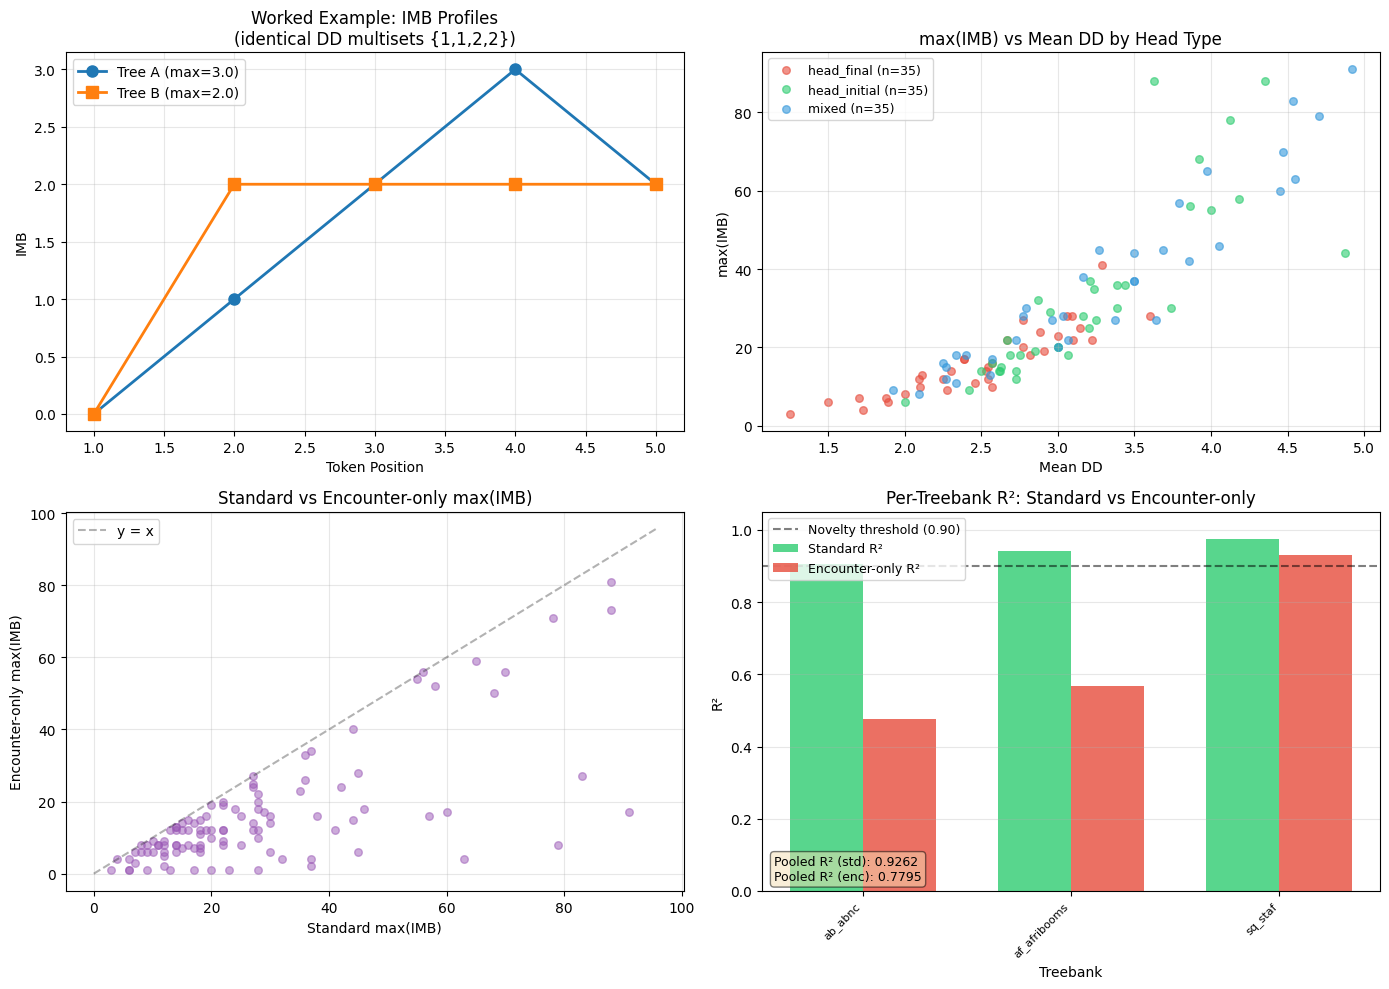

Figure saved to imb_analysis_results.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Worked example IMB profiles ---
ax = axes[0, 0]
positions = list(range(1, 6))
ax.plot(positions, imb_a, 'o-', label=f'Tree A (max={feat_a["max_imb"]})', linewidth=2, markersize=8)
ax.plot(positions, imb_b, 's-', label=f'Tree B (max={feat_b["max_imb"]})', linewidth=2, markersize=8)
ax.set_xlabel("Token Position")
ax.set_ylabel("IMB")
ax.set_title("Worked Example: IMB Profiles\n(identical DD multisets {1,1,2,2})")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: max(IMB) vs mean DD by head type ---
ax = axes[0, 1]
colors = {"head_final": "#e74c3c", "head_initial": "#2ecc71", "mixed": "#3498db"}
for ht, color in colors.items():
    subset = df[df["head_type"] == ht]
    if len(subset) > 0:
        ax.scatter(subset["mean_dd"], subset["max_imb"], alpha=0.6, s=30,
                   c=color, label=f"{ht} (n={len(subset)})")
ax.set_xlabel("Mean DD")
ax.set_ylabel("max(IMB)")
ax.set_title("max(IMB) vs Mean DD by Head Type")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Standard vs encounter-only max(IMB) ---
ax = axes[1, 0]
ax.scatter(df["max_imb"], df["max_imb_enc"], alpha=0.5, s=30, c="#9b59b6")
lims = [0, max(df["max_imb"].max(), df["max_imb_enc"].max()) * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.3, label="y = x")
ax.set_xlabel("Standard max(IMB)")
ax.set_ylabel("Encounter-only max(IMB)")
ax.set_title("Standard vs Encounter-only max(IMB)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 4: Regression R² summary ---
ax = axes[1, 1]
r2_data = []
for tb_id, res in per_treebank_results.items():
    if res.get("r2_std") is not None and res.get("r2_enc") is not None:
        r2_data.append({
            "treebank": tb_id,
            "head_type": res.get("head_type", "mixed"),
            "r2_std": res["r2_std"],
            "r2_enc": res["r2_enc"],
        })

if r2_data:
    r2_df = pd.DataFrame(r2_data)
    bar_width = 0.35
    x = np.arange(len(r2_df))
    bars1 = ax.bar(x - bar_width/2, r2_df["r2_std"], bar_width, label="Standard R²",
                   color="#2ecc71", alpha=0.8)
    bars2 = ax.bar(x + bar_width/2, r2_df["r2_enc"], bar_width, label="Encounter-only R²",
                   color="#e74c3c", alpha=0.8)
    ax.axhline(y=0.90, color='k', linestyle='--', alpha=0.5, label="Novelty threshold (0.90)")
    ax.set_xlabel("Treebank")
    ax.set_ylabel("R²")
    ax.set_title("Per-Treebank R²: Standard vs Encounter-only")
    ax.set_xticks(x)
    ax.set_xticklabels(r2_df["treebank"], rotation=45, ha="right", fontsize=8)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

    # Add pooled R² annotation
    ax.text(0.02, 0.02,
            f"Pooled R² (std): {pooled_results['standard']['r2']:.4f}\n"
            f"Pooled R² (enc): {pooled_results['encounter_only']['r2']:.4f}",
            transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig("imb_analysis_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to imb_analysis_results.png")